# Import and load data

In [1]:
# 1) Imports & Reproducibility (Fixed)
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


In [2]:
# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)
print (X_all, y_all)
X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)

print(X_all.min(), X_all.max())
print(X_all.mean(), X_all.std())


[[[ 6.75679550e+01 -3.56363373e+01 -5.97267532e+01 ... -5.06509438e+01
   -1.13689315e+00 -2.15508709e+01]
  [ 9.13680496e+01  4.66889534e+01  1.93249836e+01 ...  2.85140991e+01
    7.78668289e+01 -3.06009712e+01]
  [ 1.51674442e+01 -7.72831726e+01  4.45090218e+01 ... -5.81257439e+00
    2.03041382e+01 -1.66790943e+01]
  ...
  [-7.28439331e+01  2.36996708e+01  2.43501987e+01 ... -3.74543991e+01
    5.47884331e+01 -5.49818726e+01]
  [ 4.79495926e+01 -2.07007980e+01  1.10929747e+01 ...  8.72471619e+00
   -2.53845348e+01 -4.91702538e+01]
  [ 2.12194290e+01  1.15045921e+02  1.13001442e+01 ... -2.53499955e-01
   -5.74461594e+01  8.87677574e+00]]

 [[-1.79431839e+01 -4.58447886e+00  2.16985054e+01 ...  6.31714249e+00
    3.10616493e+01  4.70233083e-01]
  [-4.44159470e+01  3.56253777e+01  4.88908482e+00 ...  3.51508293e+01
    2.20228481e+01  2.41937141e+01]
  [-1.81326962e+01  3.36153889e+00 -2.31999626e+01 ...  3.11663246e+01
   -3.04850445e+01  2.77575016e+01]
  ...
  [-4.11730194e+01 -3.5

# Split the data and train model


In [3]:
# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


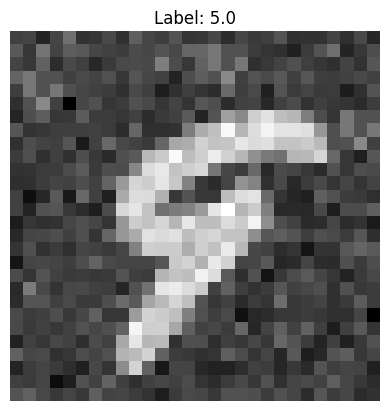

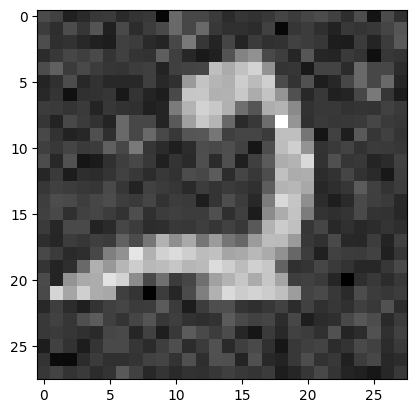

In [4]:
# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()

plt.imshow(X_all[idx], cmap="gray")


In [5]:
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Labels:", np.unique(y_all))
print("Min/Max:", X_all.min(), X_all.max())

X_all shape: (10000, 28, 28, 1)
y_all shape: (10000,)
Labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
Min/Max: -4.590059 4.5101104


# Check what kind of the data mnist.hupsista?

TensorFlow: 2.20.0
[[[ 6.75679550e+01 -3.56363373e+01 -5.97267532e+01 ... -5.06509438e+01
   -1.13689315e+00 -2.15508709e+01]
  [ 9.13680496e+01  4.66889534e+01  1.93249836e+01 ...  2.85140991e+01
    7.78668289e+01 -3.06009712e+01]
  [ 1.51674442e+01 -7.72831726e+01  4.45090218e+01 ... -5.81257439e+00
    2.03041382e+01 -1.66790943e+01]
  ...
  [-7.28439331e+01  2.36996708e+01  2.43501987e+01 ... -3.74543991e+01
    5.47884331e+01 -5.49818726e+01]
  [ 4.79495926e+01 -2.07007980e+01  1.10929747e+01 ...  8.72471619e+00
   -2.53845348e+01 -4.91702538e+01]
  [ 2.12194290e+01  1.15045921e+02  1.13001442e+01 ... -2.53499955e-01
   -5.74461594e+01  8.87677574e+00]]

 [[-1.79431839e+01 -4.58447886e+00  2.16985054e+01 ...  6.31714249e+00
    3.10616493e+01  4.70233083e-01]
  [-4.44159470e+01  3.56253777e+01  4.88908482e+00 ...  3.51508293e+01
    2.20228481e+01  2.41937141e+01]
  [-1.81326962e+01  3.36153889e+00 -2.31999626e+01 ...  3.11663246e+01
   -3.04850445e+01  2.77575016e+01]
  ...
  [-

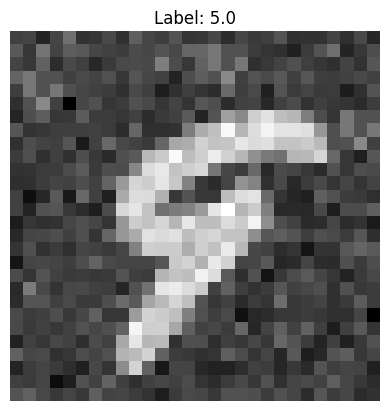

 X_all data type: <class 'numpy.ndarray'>
Kiểu dữ liệu y_all: <class 'numpy.ndarray'>
Shape X_all: (10000, 28, 28, 1)
Shape y_all: (10000,)
dtype of X_all: float32
dtype of y_all: float32
labels in y_all: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
how many labels??: 10
min of X_all: -11.2149935
max of X_all: 10.646683


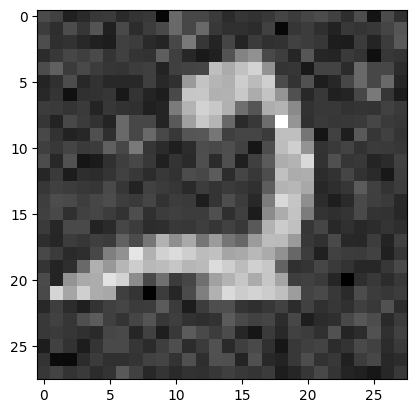

In [1]:
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pickle
import numpy as np

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

with open("mnist.hupsista", "rb") as f:
    X_all, y_all = pickle.load(f)
    # print (X_all, y_all)
X_all = X_all.astype('float32')





# 2) Load Data (Fixed)
# Expects a pickle file 'mnist.hupsista' containing (X, y) as numpy arrays.
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)
print (X_all, y_all)
X_all = X_all.astype('float32')
# Normalize to [0,1]
# if X_all.max() > 1.0:
#     X_all /= 255.0

X_all = (X_all - X_all.mean()) / X_all.std()
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)

print(X_all.min(), X_all.max())
print(X_all.mean(), X_all.std())




# 3) Create Train/Val/Test Splits (Fixed)
# Hold-out test once; then split train/val from the remainder.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


# 4) Quick Visual Check (Fixed)
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()

plt.imshow(X_all[idx], cmap="gray")

print(" X_all data type:", type(X_all))
print("Kiểu dữ liệu y_all:", type(y_all))

print("Shape X_all:", X_all.shape)
print("Shape y_all:", y_all.shape)

print("dtype of X_all:", X_all.dtype)
print("dtype of y_all:", y_all.dtype)

print("labels in y_all:", np.unique(y_all))
print("how many labels??:", len(np.unique(y_all)))

print("min of X_all:", X_all.min())
print("max of X_all:", X_all.max())

In [7]:
X_all = (X_all - X_all.mean()) / X_all.std()

In [8]:
print(X_all.min(), X_all.max())
print(X_all.mean(), X_all.std())

-11.2149935 10.646683
3.300881e-09 1.0


In [9]:
# Add channel dimension for CNN
X_all = X_all[..., None]

print(X_all.shape)

(10000, 28, 28, 1)


In [10]:
print(X_all.shape)
print(y_all.shape)

(10000, 28, 28, 1)
(10000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)


### just checking train data if it correct

In [12]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

print("Train labels:", np.unique(y_train))
print("Val labels:", np.unique(y_val))

X_train: (8000, 28, 28, 1)
X_val: (2000, 28, 28, 1)
y_train: (8000,)
y_val: (2000,)
Train labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
Val labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


# Start to build a Model
- My goal is build the model that not only high accuracy but also has low total params, for getting higher Net_score in the end.

1. Model 1
- using Conv2d and Maxpooling

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,698 (104.29 KB)

 Trainable params: 26,698 (104.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.count_params()

26698

try ading early stop

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2720 - loss: 2.1128 - val_accuracy: 0.3945 - val_loss: 1.9238
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4370 - loss: 1.8197 - val_accuracy: 0.4360 - val_loss: 1.7815
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4789 - loss: 1.6899 - val_accuracy: 0.4595 - val_loss: 1.6948
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4988 - loss: 1.5946 - val_accuracy: 0.4795 - val_loss: 1.6329
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5101 - loss: 1.5199 - val_accuracy: 0.4845 - val_loss: 1.5880
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5235 - loss: 1.4572 - val_accuracy: 0.4895 - val_loss: 1.5548
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5372 - loss: 1.3840 - val_accuracy: 0.4930 - val_loss: 1.5242
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5516 - loss: 1.3178 - val_accuracy: 0.

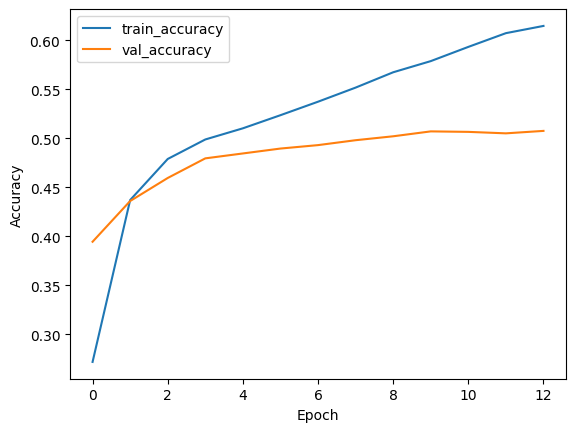

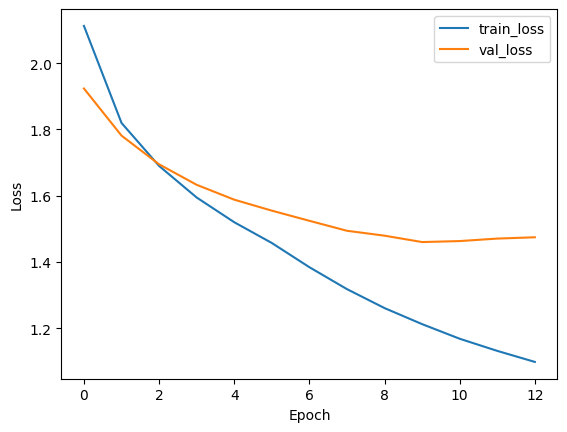

In [17]:
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Try model 2:
- Normally, after using Convolution classes to extract features, we often use the Flatten() class to flatten the data and then append it to the Dense class. This method dramatically increases the number of parameters.

Instead of flattening all pixels into a long row, GAP calculates the average of an entire "feature map". 
- If we have an output from the Conv layer of $(7, 7, 64)$ (i.e., 64 images of size $7 \times 7$), 
- Flatten() will produce: 7*7*64 = 3,136 nodes.
- GlobalAveragePooling2D() will only produce: 64 nodes (each node being the average of a $7 \times 7$ image).

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

model2 = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(16, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,690 (6.60 KB)

 Trainable params: 1,690 (6.60 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

model2.count_params()

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1185 - loss: 2.2899 - val_accuracy: 0.1250 - val_loss: 2.2757
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1355 - loss: 2.2636 - val_accuracy: 0.1475 - val_loss: 2.2519
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1702 - loss: 2.2340 - val_accuracy: 0.2040 - val_loss: 2.2145
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1995 - loss: 2.1902 - val_accuracy: 0.2035 - val_loss: 2.1666
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2165 - loss: 2.1426 - val_accuracy: 0.2225 - val_loss: 2.1181
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2342 - loss: 2.1009 - val_accuracy: 0.2375 - val_loss: 2.0802
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2446 - loss: 2.0711 - val_accuracy: 0.2375 - val_loss: 2.0584
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2489 - loss: 2.0508 - val_accuracy: 0.

1690

Model 3:
- reduce the param in dense lauer, campare with first model

In [20]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model3 = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,978 (54.60 KB)

 Trainable params: 13,978 (54.60 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)


model3.count_params()

# model3.save("mnist_noise_model.keras")

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2180 - loss: 2.1569 - val_accuracy: 0.3280 - val_loss: 1.9883
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3736 - loss: 1.8834 - val_accuracy: 0.4055 - val_loss: 1.8417
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4399 - loss: 1.7449 - val_accuracy: 0.4560 - val_loss: 1.7476
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4726 - loss: 1.6509 - val_accuracy: 0.4795 - val_loss: 1.6638
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4875 - loss: 1.5714 - val_accuracy: 0.4875 - val_loss: 1.6026
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4994 - loss: 1.5096 - val_accuracy: 0.4965 - val_loss: 1.5536
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5077 - loss: 1.4582 - val_accuracy: 0.4995 - val_loss: 1.5205
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5188 - loss: 1.4135 - val_accuracy: 0.

13978

Try model4

In [22]:
from tensorflow.keras import layers, models, callbacks

model4 = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    
    tf.keras.layers.Conv2D(filters=8, kernel_size=5, activation="relu"), # convelutional layer
    layers.MaxPool2D(pool_size=2),
    
    tf.keras.layers.Conv2D(18, 5, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    
    layers.Flatten(),
    
    tf.keras.layers.Dense(48, activation="relu"), # dense layer
    layers.Dropout(0.5), #dropout is turining part of neurons while 
    # training to prevent overfitting.

    layers.Dense(10, activation='softmax')
])

model4.compile(
    optimizer='adam', # switching to adam as more "adaptive" and faster then SGD
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# this function stop the training when the validation loss stops improving 
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# callbacks.EarlyStopping creates callback that Keras will use during the training
# monitor='val_loss' it is saying that this function will evaluate the model by validation loss 
# patience=3 in this example if val_loss will not improve in 3 epochs it will trigger the function
# restore_best_weights=True after stopping the weights in model are restored from the best epoch

history = model4.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), verbose=1)
print()


model4.summary()
model4.count_params()



Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2111 - loss: 2.1742 - val_accuracy: 0.3860 - val_loss: 1.9589
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3651 - loss: 1.9375 - val_accuracy: 0.4455 - val_loss: 1.8076
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4062 - loss: 1.8118 - val_accuracy: 0.4720 - val_loss: 1.6533
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4380 - loss: 1.6708 - val_accuracy: 0.5055 - val_loss: 1.5044
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4627 - loss: 1.5595 - val_accuracy: 0.5125 - val_loss: 1.4101
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4782 - loss: 1.4857 - val_accuracy: 0.5260 - val_loss: 1.3541
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4940 - loss: 1.4312 - val_accuracy: 0.5260 - val_loss: 1.3180
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5064 - loss: 1.3844 - val_accuracy: 0.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 18)       │         3,618 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 18)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 48)             │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,566 (213.15 KB)

 Trainable params: 18,188 (71.05 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36,378 (142.11 KB)

18188

In [23]:
# def evaluate_and_score(model, X_test_data, y_test_labels):
#     # 1. Dự đoán trên tập dữ liệu 10.000 ảnh
#     predictions = model.predict(X_test_data)
#     y_pred = np.argmax(predictions, axis=1)
    
#     # 2. Tính tổng số câu đúng (N)
#     n_correct = np.sum(y_pred == y_test_labels)
    
#     # 3. Tính Tiền thưởng (Reward) theo bậc thang
#     if n_correct <= 5000:
#         reward = n_correct * 100
#     elif n_correct <= 6000:
#         reward = (5000 * 100) + (n_correct - 5000) * 200
#     else:
#         reward = (5000 * 100) + (1000 * 200) + (n_correct - 6000) * 1000
        
#     # 4. Lấy số lượng tham số của model
#     total_params = model.count_params()
    
#     # 5. Tính Net Score
#     net_score = reward - total_params
    
#     # In kết quả
#     print(f"Số câu đúng: {n_correct}/10,000")
#     print(f"Tiền thưởng: {reward} €")
#     print(f"Tổng tham số: {total_params}")
#     print(f"NET SCORE: {net_score}")
    
#     return net_score


def evaluate_and_score(model, X_test_data, y_test_labels):
    predictions = model.predict(X_test_data, verbose=0)
    y_pred = np.argmax(predictions, axis=1)

    n_correct = np.sum(y_pred == y_test_labels)

    if n_correct <= 5000:
        reward = n_correct * 100
    elif n_correct <= 6000:
        reward = (5000 * 100) + (n_correct - 5000) * 200
    else:
        reward = (5000 * 100) + (1000 * 200) + (n_correct - 6000) * 1000

    total_params = model.count_params()
    net_score = reward - total_params

    print(f"Số câu đúng: {n_correct}/{len(y_test_labels)}")
    print(f"Accuracy: {n_correct / len(y_test_labels):.4f}")
    print(f"Tiền thưởng: {reward} €")
    print(f"Tổng tham số: {total_params}")
    print(f"NET SCORE: {net_score}")

    return net_score

In [24]:
# Đánh giá Model 1
model.save("my_model_final1.keras")
tf.keras.utils.plot_model(model, to_file='model1_diagram.png', show_shapes=True)
score1 = evaluate_and_score(model, X_test, y_test)

print("-" * 30)

# Đánh giá Model 2
model2.save("my_model_final2.keras")
tf.keras.utils.plot_model(model2, to_file='model2_diagram.png', show_shapes=True)
score2 = evaluate_and_score(model2, X_test, y_test)

print("-" * 30)

# Đánh giá Model 3
model3.save("my_model_final3.keras")
tf.keras.utils.plot_model(model3, to_file='model3_diagram.png', show_shapes=True)
score3 = evaluate_and_score(model3, X_test, y_test)
print("-" * 30)
# Đánh giá Model 4
model4.save("my_model_final4.keras")
tf.keras.utils.plot_model(model4, to_file='model4_diagram.png', show_shapes=True)
score4 = evaluate_and_score(model4, X_test, y_test)
print("-" * 30)
# Tổng kết
print("\nBẢNG XẾP HẠNG NET SCORE:")
results = {"Model 1": score1, "Model 2": score2, "Model 3": score3,"Model 4": score4}
for name, score in results.items():
    print(f"{name}: {score} điểm")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Số câu đúng: 750/2000
Accuracy: 0.3750
Tiền thưởng: 75000 €
Tổng tham số: 26698
NET SCORE: 48302
------------------------------
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Số câu đúng: 288/2000
Accuracy: 0.1440
Tiền thưởng: 28800 €
Tổng tham số: 1690
NET SCORE: 27110
------------------------------
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Số câu đúng: 214/2000
Accuracy: 0.1070
Tiền thưởng: 21400 €
Tổng tham số: 13978
NET SCORE: 7422
------------------------------
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Số câu đúng: 584/2000
Accuracy: 0.2920
Tiền thưởng: 58400 €
Tổng tham số: 18188
NET SCORE: 40212
------------------------------

BẢNG XẾP HẠNG NET SCORE:
Model 1: 48302 điểm


In [25]:
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

print("Model 1 input shape:", model.input_shape)
print("Model 2 input shape:", model2.input_shape)
print("Model 3 input shape:", model3.input_shape)
print("Model 4 input shape:", model4.input_shape)

X_all shape: (10000, 28, 28, 1)
y_all shape: (10000,)
Model 1 input shape: (None, 28, 28, 1)
Model 2 input shape: (None, 28, 28, 1)
Model 3 input shape: (None, 28, 28, 1)
Model 4 input shape: (None, 28, 28, 1)


In [26]:
print(type(X_all))
print(X_all.dtype)
print(np.min(X_all), np.max(X_all))
print(np.isnan(X_all).sum())
print(np.isinf(X_all).sum())

<class 'numpy.ndarray'>
float32
-11.2149935 10.646683
0
0


In [27]:
# Đánh giá Model 1
model.save("my_model_final1.keras")
tf.keras.utils.plot_model(model, to_file='model1_diagram.png', show_shapes=True)
score1 = evaluate_and_score(model, X_all, y_all)

print("-" * 30)

# Đánh giá Model 2
model2.save("my_model_final2.keras")
tf.keras.utils.plot_model(model2, to_file='model2_diagram.png', show_shapes=True)
score2 = evaluate_and_score(model2, X_all, y_all)

print("-" * 30)

# Đánh giá Model 3
model3.save("my_model_final3.keras")
tf.keras.utils.plot_model(model3, to_file='model3_diagram.png', show_shapes=True)
score3 = evaluate_and_score(model3, X_all, y_all)
print("-" * 30)
# Đánh giá Model 4
model4.save("my_model_final4.keras")
tf.keras.utils.plot_model(model4, to_file='model4_diagram.png', show_shapes=True)
score4 = evaluate_and_score(model4, X_all, y_all)
print("-" * 30)
# Tổng kết
print("\nBẢNG XẾP HẠNG NET SCORE:")
results = {"Model 1": score1, "Model 2": score2, "Model 3": score3, "Model 4": score4}
for name, score in results.items():
    print(f"{name}: {score} điểm")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_test min/max:", X_test.min(), X_test.max())
print("y_test unique:", np.unique(y_test))

X_test shape: (2000, 28, 28, 1)
y_test shape: (2000,)
X_test min/max: -4.590059 4.5101104
y_test unique: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [ ]:
predictions = model3.predict(X_test, verbose=0)
y_pred = np.argmax(predictions, axis=1)
acc = np.mean(y_pred == y_test)

print("Correct:", np.sum(y_pred == y_test))
print("Accuracy:", acc)

Correct: 262
Accuracy: 0.131


In [ ]:
# 1. Lưu file .keras theo yêu cầu
model.save("my_model_final.keras")

# 2. Vẽ sơ đồ model (Diagram)
tf.keras.utils.plot_model(model, to_file='model_diagram.png', show_shapes=True)

# 3. Chạy hàm tính điểm thực tế trên tập Test
# Lưu ý: Đảm bảo X_test và y_test có đủ 10.000 mẫu
final_score = evaluate_and_score(model, X_test, y_test)

Số câu đúng: 344/2000
Accuracy: 0.1720
Tiền thưởng: 34400 €
Tổng tham số: 26698
NET SCORE: 7702


In [ ]:
# 1. Lưu file .keras theo yêu cầu
model2.save("my_model_final2.keras")

# 2. Vẽ sơ đồ model (Diagram)
tf.keras.utils.plot_model(model2, to_file='model_diagram.png', show_shapes=True)

# 3. Chạy hàm tính điểm thực tế trên tập Test
# Lưu ý: Đảm bảo X_test và y_test có đủ 10.000 mẫu
final_score = evaluate_and_score(model2, X_test, y_test)

Số câu đúng: 251/2000
Accuracy: 0.1255
Tiền thưởng: 25100 €
Tổng tham số: 1690
NET SCORE: 23410


In [ ]:
# 1. Lưu file .keras theo yêu cầu
model3.save("my_model_final3.keras")

# 2. Vẽ sơ đồ model (Diagram)
tf.keras.utils.plot_model(model3, to_file='model_diagram.png', show_shapes=True)

# 3. Chạy hàm tính điểm thực tế trên tập Test
# Lưu ý: Đảm bảo X_test và y_test có đủ 10.000 mẫu
final_score = evaluate_and_score(model3, X_test, y_test)

Số câu đúng: 262/2000
Accuracy: 0.1310
Tiền thưởng: 26200 €
Tổng tham số: 13978
NET SCORE: 12222


In [28]:
a = evaluate_and_score(model3, X_test, y_test)
b = evaluate_and_score(model3, X_test, y_test)

print("a =", a)
print("b =", b)

Số câu đúng: 214/2000
Accuracy: 0.1070
Tiền thưởng: 21400 €
Tổng tham số: 13978
NET SCORE: 7422
Số câu đúng: 214/2000
Accuracy: 0.1070
Tiền thưởng: 21400 €
Tổng tham số: 13978
NET SCORE: 7422
a = 7422
b = 7422
